# HALO-AC3 Arctic Leads Batch Processing
This notebook demonstrates batch processing of HALO-AC3 data using PyRadtran.

In [28]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/HALO-AC3_HALO_solar.yaml')
import logging
# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

## Load and prepare data
Load the BBR data and surface type information from Nils Risse's dataset

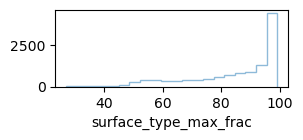

In [29]:
ds_bbr = bbr_halo = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO.nc')
surface_type = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/Nils_Risse/data/HALO-AC3_VELOX_surface_type_fraction_full_FOV.nc').drop_duplicates(dim='time', keep='last')
surface_type_5deg = surface_type['histogram_label']
max_surface_type = surface_type_5deg.argmax(dim='label_bin')
surface_type['surface_max_frac'] = surface_type_5deg.max(dim='label_bin')


ds_bbr = ds_bbr.interp_like(surface_type['time'])

ds_bbr['surface_type'] = max_surface_type
ds_bbr['surface_type_max_frac'] = surface_type['surface_max_frac']
ds_bbr['surface_type_max_frac'].plot.hist(bins=20, histtype='step', color='C0', alpha=0.5, label='Max surface type fraction', figsize=(3, 1))
ds_bbr = ds_bbr.where(ds_bbr['surface_type_max_frac'] > 0.9, drop=True)

## Prepare a cropped dataset for efficient processing
Create a coarsened subset for faster simulations

In [30]:
ds_crop = ds_bbr[['time', 'lat', 'lon', 'alt']].resample(time='60S').mean().dropna('time').rename(
    {'lat': 'latitude', 'lon': 'longitude'}
)

ds_crop['time'] = ds_crop['time'].dt.round('1s')
ds_crop['altitude'] = np.arange(0, 15, 1)
ds_crop

/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/groupers.py:392: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  self.index_grouper = pd.Grouper(
2025-05-07 18:20:19,600 - flox - INFO - Entering _validate_reindex: reindex is None
2025-05-07 18:20:19,601 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-05-07 18:20:19,601 - flox - INFO - _choose_engine: Choosing 'flox'
2025-05-07 18:20:19,603 - flox - INFO - Entering _validate_reindex: reindex is None
2025-05-07 18:20:19,604 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-05-07 18:20:19,604 - flox - INFO - _choose_engine: Choosing 'flox'
2025-05-07 18:20:19,606 - flox - INFO - Entering _validate_reindex: reindex is None
2025-05-07 18:20:19,606 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-05-07 18:20:19,607 - flox - INFO - _choose_engine: Choosing 'flox'


<xarray.Dataset> Size: 15kB
Dimensions:    (time: 459, altitude: 15)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2022-03-14T10:30:00 ... 2022-04-11T1...
  * altitude   (altitude) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
Data variables:
    latitude   (time) float64 4kB 79.12 79.42 79.5 82.88 ... 85.99 85.49 85.27
    longitude  (time) float64 4kB 27.21 27.15 27.13 4.178 ... 17.16 12.62 11.03
    alt        (time) float64 4kB 1.096e+04 1.095e+04 ... 8.773e+03 9.806e+03
Attributes:
    title:                Broadband radiation measured by BACARDI during HALO...
    mission:              HALO-AC3
    platform:             HALO
    instrument:           BACARDI
    research_flight_day:  2022/04/08
    version:              R1
    date_last_revised:    2023/10/25
    comment:              BACARDI raw data was processed by DLR; contact Andr...
    contact:              Anna Luebke, Andre Ehrlich, University Leipzig; ema...

## Add albedo values to the dataset
Add albedo as a coordinate variable based on surface types

In [31]:
# Map surface types to typical albedo values for Arctic surfaces
surface_albedo_map = {
    0: 0.07,  # Open water
    1: 0.30,  # Nilas/gray ice
    2: 0.60,  # Young white ice
    3: 0.80   # Thick first-year ice
}

# Function to find the nearest surface type for a timestamp
def get_nearest_surface_type(time):
    # Convert to pandas Timestamp for easier comparison
    pd_time = pd.Timestamp(time.values)
    
    # Find the closest time in the original dataset
    time_diffs = abs(pd.DatetimeIndex(ds_bbr.time.values) - pd_time)
    closest_idx = time_diffs.argmin()
    
    # Get the surface type for that time
    return ds_bbr.surface_type.values[closest_idx]

# Get surface types for each time point in the crop dataset
surface_types = np.array([get_nearest_surface_type(t) for t in ds_crop.time])
albedo_values = np.array([surface_albedo_map.get(int(st), 0.6) for st in surface_types])

ds_crop['albedo'] = (('time',), albedo_values)

# Print the result to verify
print("Surface types for the crop times:", surface_types)
print("Corresponding albedo values:", albedo_values)
ds_crop

Surface types for the crop times: [0. 0. 0. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 0. 0. 0. 1. 0. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 2. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 2. 2. 2. 2. 2. 2. 3. 3. 2. 3. 3. 2. 2. 2. 2. 2. 3. 3. 3. 2. 2. 2. 3.
 3. 3. 3. 3. 3. 3. 3. 2. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 1. 3. 2. 3. 3. 3. 3. 3. 3. 2. 2. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 1. 2. 3. 3. 1. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 1. 3. 3. 3. 3. 3. 3. 3. 3. 3. 1. 3. 3. 3. 1. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 1. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 2. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3

<xarray.Dataset> Size: 18kB
Dimensions:    (time: 459, altitude: 15)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2022-03-14T10:30:00 ... 2022-04-11T1...
  * altitude   (altitude) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
Data variables:
    latitude   (time) float64 4kB 79.12 79.42 79.5 82.88 ... 85.99 85.49 85.27
    longitude  (time) float64 4kB 27.21 27.15 27.13 4.178 ... 17.16 12.62 11.03
    alt        (time) float64 4kB 1.096e+04 1.095e+04 ... 8.773e+03 9.806e+03
    albedo     (time) float64 4kB 0.07 0.07 0.07 0.6 0.6 ... 0.8 0.8 0.8 0.8 0.8
Attributes:
    title:                Broadband radiation measured by BACARDI during HALO...
    mission:              HALO-AC3
    platform:             HALO
    instrument:           BACARDI
    research_flight_day:  2022/04/08
    version:              R1
    date_last_revised:    2023/10/25
    comment:              BACARDI raw data was processed by DLR; contact Andr...
    contact:              Anna Luebke, Andre Ehrlich, University Leipzig; ema...

(array([ 2.,  4.,  5., 14., 18., 18., 46., 49., 70., 73., 29., 20., 13.,
         4.,  1.,  1.,  0.,  2.,  0.,  2.]),
 array([0.43580413, 0.4611608 , 0.48651747, 0.51187414, 0.5372308 ,
        0.56258747, 0.58794414, 0.61330081, 0.63865748, 0.66401414,
        0.68937081, 0.71472748, 0.74008415, 0.76544082, 0.79079749,
        0.81615415, 0.84151082, 0.86686749, 0.89222416, 0.91758083,
        0.94293749]),
 [<matplotlib.patches.Polygon at 0x7f4618dea750>])

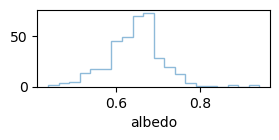

In [32]:
ds_crop['albedo'] = ds_bbr['albedo'].interp_like(ds_crop['time'])
ds_crop['albedo'] = ds_crop['albedo'].where(ds_crop['albedo'] < 1, drop=True)
ds_crop['albedo'].plot.hist(bins=20, histtype='step', color='C0', alpha=0.5, label='Albedo', figsize=(3, 1))

## Run the simulation
Use the PyRadtran accessor to run a simulation using the dataset with albedo values

In [33]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
ds_sim = ds_crop.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    output_path='../work/halo_ac3_results.nc',
    albedo_var='albedo',
)

print("\nSimulation complete!")
ds_sim

2025-05-07 18:20:20,001 - pyradtran.config - INFO - Loading configuration from: ../config/HALO-AC3_HALO_solar.yaml
2025-05-07 18:20:20,009 - pyradtran.config - INFO - Configuration loaded successfully.
2025-05-07 18:20:20,011 - pyradtran.interface - INFO - Overriding configuration altitude with 15 levels from dataset: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
2025-05-07 18:20:20,012 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-05-07 18:20:20,021 - pyradtran.utils - INFO - Found and parsed 323 radiosonde files.


Running batch spectral simulation...


2025-05-07 18:20:20,202 - pyradtran.interface - INFO - Running 459 simulations across time/location points...
2025-05-07 18:20:20,472 - pyradtran.core - DEBUG - Time 2022-03-14 10:30:00 -> Closest Sonde: 20220314_37586SOD.dat
2025-05-07 18:20:20,473 - pyradtran.core - DEBUG - Time 2022-03-14 10:32:00 -> Closest Sonde: 20220314_37586SOD.dat
2025-05-07 18:20:20,475 - pyradtran.core - DEBUG - Time 2022-03-14 10:33:00 -> Closest Sonde: 20220314_37586SOD.dat
2025-05-07 18:20:20,478 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20220314_103000_i68gevoj.inp
2025-05-07 18:20:20,478 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20220314_103200_m58j0lvi.inp
2025-05-07 18:20:20,479 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work


Simulation complete!


<xarray.Dataset> Size: 452kB
Dimensions:    (time: 459, altitude: 15)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2022-03-14T10:30:00 ... 2022-04-11T1...
  * altitude   (altitude) float64 120B 0.0 1.0 2.0 3.0 ... 11.0 12.0 13.0 14.0
Data variables:
    latitude   (time) float64 4kB 79.12 79.42 79.5 82.88 ... 85.99 85.49 85.27
    longitude  (time) float64 4kB 27.21 27.15 27.13 4.178 ... 17.16 12.62 11.03
    zout       (time, altitude) float64 55kB 0.0 1.0 2.0 3.0 ... nan nan nan nan
    sza        (time, altitude) float64 55kB 81.97 81.97 81.97 ... nan nan nan
    edir       (time, altitude) float64 55kB 8.963e+04 9.839e+04 ... nan nan
    eglo       (time, altitude) float64 55kB 1.142e+05 1.214e+05 ... nan nan
    edn        (time, altitude) float64 55kB 2.457e+04 2.297e+04 ... nan nan
    eup        (time, altitude) float64 55kB 7.289e+04 7.367e+04 ... nan nan
    enet       (time, altitude) float64 55kB 4.131e+04 4.77e+04 ... nan nan
    albedo     (time, altitude) float64 55kB 0.6383 0.607 0.5815 ... nan nan nan
Attributes:
    generated_by:     pyradtran
    altitude_levels:  15 levels (km): 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0,...

In [36]:
# Load the solar flux data from Gueymard 2003 dataset
import pandas as pd

ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2533301/782123713.py:4: SyntaxWarning: invalid escape sequence '\s'
  ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()


In [39]:
E0 = ds_e0['flux'].integrate('wavelength')
E0

<xarray.DataArray 'flux' ()> Size: 8B
array(1366151.1872347)

In [40]:
ds_sim['transmittance'] = ds_sim['eglo'] / E0

(array([ 2.,  1.,  1.,  0.,  0.,  1., 18., 25., 22., 16.,  7., 19., 58.,
        55., 31., 64., 28.,  8.,  1., 13.]),
 array([0.02721691, 0.03993373, 0.05265055, 0.06536736, 0.07808418,
        0.090801  , 0.10351781, 0.11623463, 0.12895145, 0.14166826,
        0.15438508, 0.1671019 , 0.17981871, 0.19253553, 0.20525235,
        0.21796916, 0.23068598, 0.2434028 , 0.25611961, 0.26883643,
        0.28155325]),
 [<matplotlib.patches.Polygon at 0x7f4618e43560>])

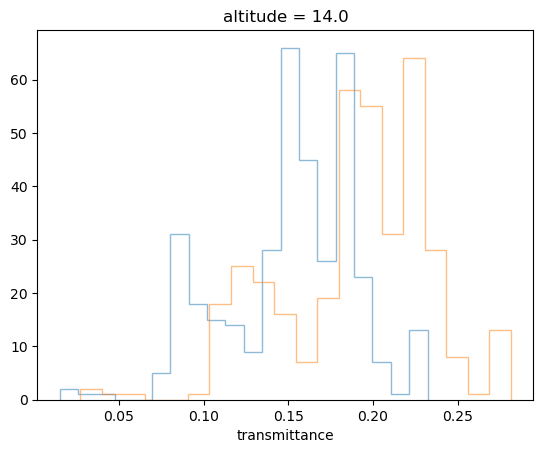

In [52]:
ds_sim['transmittance'].isel(altitude=0).plot.hist(
    bins=20,
    histtype='step',
    color='C0',
    alpha=0.5,
)
ds_sim['transmittance'].isel(altitude=-1).plot.hist(
    bins=20,
    histtype='step',
    color='C1',
    alpha=0.5,
)

(array([  30.,   62.,  146.,  302.,  556.,  729., 1225., 1018.,  675.,
         405.,  215.,   92.,   47.,   24.,    9.,    5.,    2.,    4.,
           2.,    2.]),
 array([0.4464594 , 0.47857693, 0.51069446, 0.54281199, 0.57492952,
        0.60704705, 0.63916458, 0.67128211, 0.70339964, 0.73551717,
        0.7676347 , 0.79975223, 0.83186976, 0.86398729, 0.89610482,
        0.92822235, 0.96033988, 0.99245741, 1.02457494, 1.05669247,
        1.08881   ]),
 [<matplotlib.patches.Polygon at 0x7f4618d18f50>])

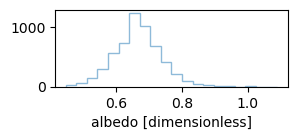

In [53]:
ds_sim.albedo.plot.hist(bins=20, histtype='step', color='C0', alpha=0.5, label='Albedo', figsize=(3, 1))

In [ ]:
ds_sim['albedo_transmittance'] = (ds_sim['albedo'].isel(altitude=0) / ds_sim['albedo'])
ds_sim['albedo_transmittance']
ds_sim['albedo_transmittance'].mean(dim='time').plot()

In [93]:
ds_sim_ = ds_sim.sel(altitude=ds_crop['alt'], method='nearest').fillna(
    ds_sim['albedo_transmittance'].mean(dim='time').sel(altitude=ds_crop['alt'], method='nearest'
    ).values
)


ds_sim_bbr = ds_sim_.interp_like(ds_bbr['time'], method='nearest')
mean = ds_sim_bbr['albedo_transmittance'].mean(dim='time').values
ds_sim_bbr['albedo_transmittance'] = ds_sim_bbr['albedo_transmittance'].fillna(mean)


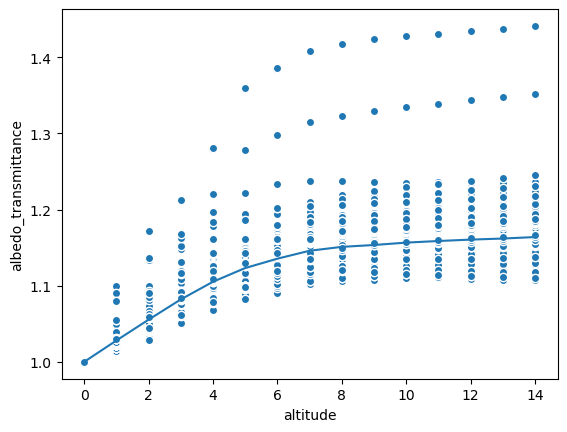

In [94]:
ds_sim['albedo_transmittance'] = (ds_sim['albedo'].isel(altitude=0) / ds_sim['albedo'])
ds_sim['albedo_transmittance']
ds_sim['albedo_transmittance'].median(dim='time').plot()

ds_sim['albedo_transmittance'].plot.scatter(
    x = 'altitude', 
    y = 'albedo_transmittance',
)

In [105]:
ds_bbr['albedo_surf'] = ds_sim_bbr['albedo_transmittance'] * ds_bbr['albedo']
ds_bbr['albedo_surf'] = ds_bbr['albedo_surf'].where(ds_bbr['albedo_surf'] < 1)

In [108]:
ds_sim_bbr['albedo_transmittance']
(ds_bbr['albedo_surf'] > 1).sum() / len(ds_bbr['albedo_surf']) 

<xarray.DataArray 'albedo_surf' ()> Size: 8B
array(0.)

In [116]:
ds_bbr

<xarray.Dataset> Size: 3MB
Dimensions:                (time: 11997, altitude: 15)
Coordinates:
  * time                   (time) datetime64[ns] 96kB 2022-03-14T10:30:10 ......
  * altitude               (altitude) float64 120B 0.0 1.0 2.0 ... 13.0 14.0
Data variables: (12/26)
    alt                    (time) float64 96kB 1.096e+04 1.096e+04 ... 9.809e+03
    lat                    (time) float64 96kB 79.11 79.11 79.11 ... 85.27 85.27
    lon                    (time) float64 96kB 27.22 27.22 27.21 ... 11.04 11.02
    sza                    (time) float64 96kB 81.47 81.47 81.47 ... 76.92 76.92
    saa                    (time) float64 96kB 182.4 182.5 182.5 ... 193.5 193.5
    F_down_solar           (time) float64 96kB 170.1 170.0 170.0 ... 274.3 274.4
    ...                     ...
    F_net_sim              (time) float64 96kB -97.11 -97.11 ... -3.432 -3.432
    CRF                    (time) float64 96kB -40.8 -41.36 ... -97.96 -98.06
    aircraft               (time) object 96kB 'HALO' 'HALO' ... 'HALO' 'HALO'
    surface_type           (time) float64 96kB 0.0 0.0 0.0 0.0 ... 3.0 3.0 3.0
    surface_type_max_frac  (time) float64 96kB 97.84 97.45 97.28 ... 97.37 97.09
    albedo_surf            (time) float64 96kB 0.6411 0.6453 ... 0.8764 0.8767
Attributes:
    title:                Broadband radiation measured by BACARDI during HALO...
    mission:              HALO-AC3
    platform:             HALO
    instrument:           BACARDI
    research_flight_day:  2022/04/08
    version:              R1
    date_last_revised:    2023/10/25
    comment:              BACARDI raw data was processed by DLR; contact Andr...
    contact:              Anna Luebke, Andre Ehrlich, University Leipzig; ema...

In [115]:
ds_bbr.to_netcdf(
    '/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO_albedo_corr.nc',
    mode='w',
    format='NETCDF4',
    unlimited_dims='time',
    encoding={'time': {'units': 'seconds since 1970-01-01T00:00:00Z'}}
)

## Examine other aspects of the simulation results

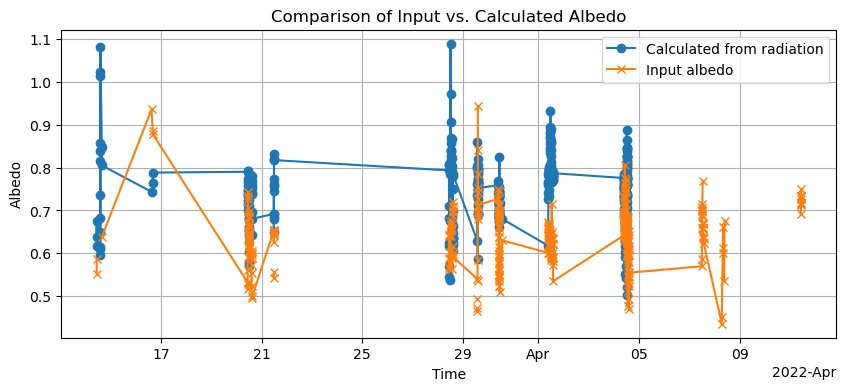

In [35]:
# Calculate albedo as ratio of upward to downward radiation
if 'eup' in ds_sim and 'eglo' in ds_sim:
    if 'altitude' in ds_sim.dims:
        # Calculate at the surface level
        surface_level = 0.0
        calculated_albedo = ds_sim.eup.sel(altitude=surface_level) / ds_sim.eglo.sel(altitude=surface_level)
        
        # Compare with input albedo
        plt.figure(figsize=(10, 4))
        calculated_albedo.plot(marker='o', label='Calculated from radiation')
        ds_crop.albedo.plot(marker='x', label='Input albedo')
        plt.title('Comparison of Input vs. Calculated Albedo')
        plt.xlabel('Time')
        plt.ylabel('Albedo')
        plt.legend()
        plt.grid(True)
        plt.show()

## Load and analyze solar flux for comparison

In [9]:
# Load the solar flux data from Gueymard 2003 dataset
import pandas as pd

ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2533301/782123713.py:4: SyntaxWarning: invalid escape sequence '\s'
  ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()


In [10]:
# Integrate over the wavelength range if we have spectral data
if 'wavelength' in ds_sim.dims:
    ds_glo_integrated = ds_sim['edir'].sel(wavelength=ds_sim.wavelength).integrate('wavelength').values
    ds_e0_integrated = ds_e0.sel(wavelength=ds_sim.wavelength, method='nearest').flux.integrate('wavelength').values
    
    print(f"Ratio of integrated direct irradiance to solar flux: {ds_glo_integrated / ds_e0_integrated}")

In [11]:
# Plot the spectral ratio if available
if 'wavelength' in ds_sim.dims:
    plt.figure(figsize=(10, 6))
    (ds_sim['edir'] / ds_e0.sel(wavelength=ds_sim.wavelength, method='nearest').flux).plot()
    plt.title('Spectral Transmittance')
    plt.ylabel('Transmittance')
    plt.xlabel('Wavelength (nm)')
    plt.grid(True)

## Load the original BBR data for comparison

In [12]:
# Reload the full BBR dataset for comparison with our simulation results
bbr_halo = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO.nc')